In [1]:
import sys
sys.path.insert(0, '/home/rudra/Documents/NeuralFieldManifold')

In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

from NeuralFieldManifold.models import DeepLagEmbed
from NeuralFieldManifold.generators import tvar
from NeuralFieldManifold.utils import train_loop, bench_loop
from NeuralFieldManifold.plottings import plot_history, plot_coefficients_by_p, plot_tvar_sample
from torchinfo import summary

from utils import pinn_processor

In [3]:
X_train, coef_train, p_train, class_id_train, X_val, coef_val, p_val, class_id_val, class_names = pinn_processor("train_data.npz", family=None)

Total samples: 1000000 | Train: 800000 | Val: 200000
Train p distribution: {np.int64(0): np.int64(160000), np.int64(1): np.int64(160000), np.int64(2): np.int64(160000), np.int64(3): np.int64(160000), np.int64(4): np.int64(160000)}
Val p distribution:   {np.int64(0): np.int64(40000), np.int64(1): np.int64(40000), np.int64(2): np.int64(40000), np.int64(3): np.int64(40000), np.int64(4): np.int64(40000)}


In [4]:
# idx_train = np.random.permutation(len(X_train))[:1000]
# X_train = X_train[idx_train]
# p_train = p_train[idx_train]

# idx_val = np.random.permutation(len(X_val))[:1000]
# X_val = X_val[idx_val]
# p_val = p_val[idx_val]
# class_id_val = class_id_val[idx_val]

In [5]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.init()
    torch.backends.cudnn.benchmark = True
    print(f"Using device: {device}")

# Move ALL data to GPU upfront - eliminates CPU->GPU transfer bottleneck
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
p_train = torch.tensor(p_train, dtype=torch.long, device=device)
X_val = torch.tensor(X_val, dtype=torch.float32, device=device)
p_val = torch.tensor(p_val, dtype=torch.long, device=device)
class_id_val = class_id_val  # numpy array

# Data already on GPU - no pin_memory/workers needed
train_loader = DataLoader(
    TensorDataset(X_train, p_train), 
    batch_size=256,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val, p_val), 
    batch_size=256
)

Using device: cuda:1


In [6]:
def do_bench_on_config(lambda_config, model=None):
    
    # hyperparameters
    n_epochs = 100
    lr = 1e-3
    max_ar_order = 6
    
    if model is None:
        # Model: n_classes=5 for p∈{2,3,4,5,6}, max_ar_order=6 for coefficient dimensions
        model = DeepLagEmbed(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
        model = model.to(device)
        # summary(model, input_size=(32, 600), device=device)

    # Train
    history = train_loop(
        model, train_loader, val_loader,
        n_epochs=n_epochs, lr=lr,
        lambda_p=lambda_config["lambda_p"], lambda_ar=lambda_config["lambda_ar"], lambda_energy=lambda_config["lambda_energy"], 
        lambda_smooth=lambda_config["lambda_smooth"], lambda_order=lambda_config["lambda_order"],
        p_max=max_ar_order, device=device
    )
    return model, history

## Base fit

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training: 100%|██████████| 100/100 [15:15<00:00,  9.15s/it, p_acc=0.333, train=37.2445, val=37.3837]


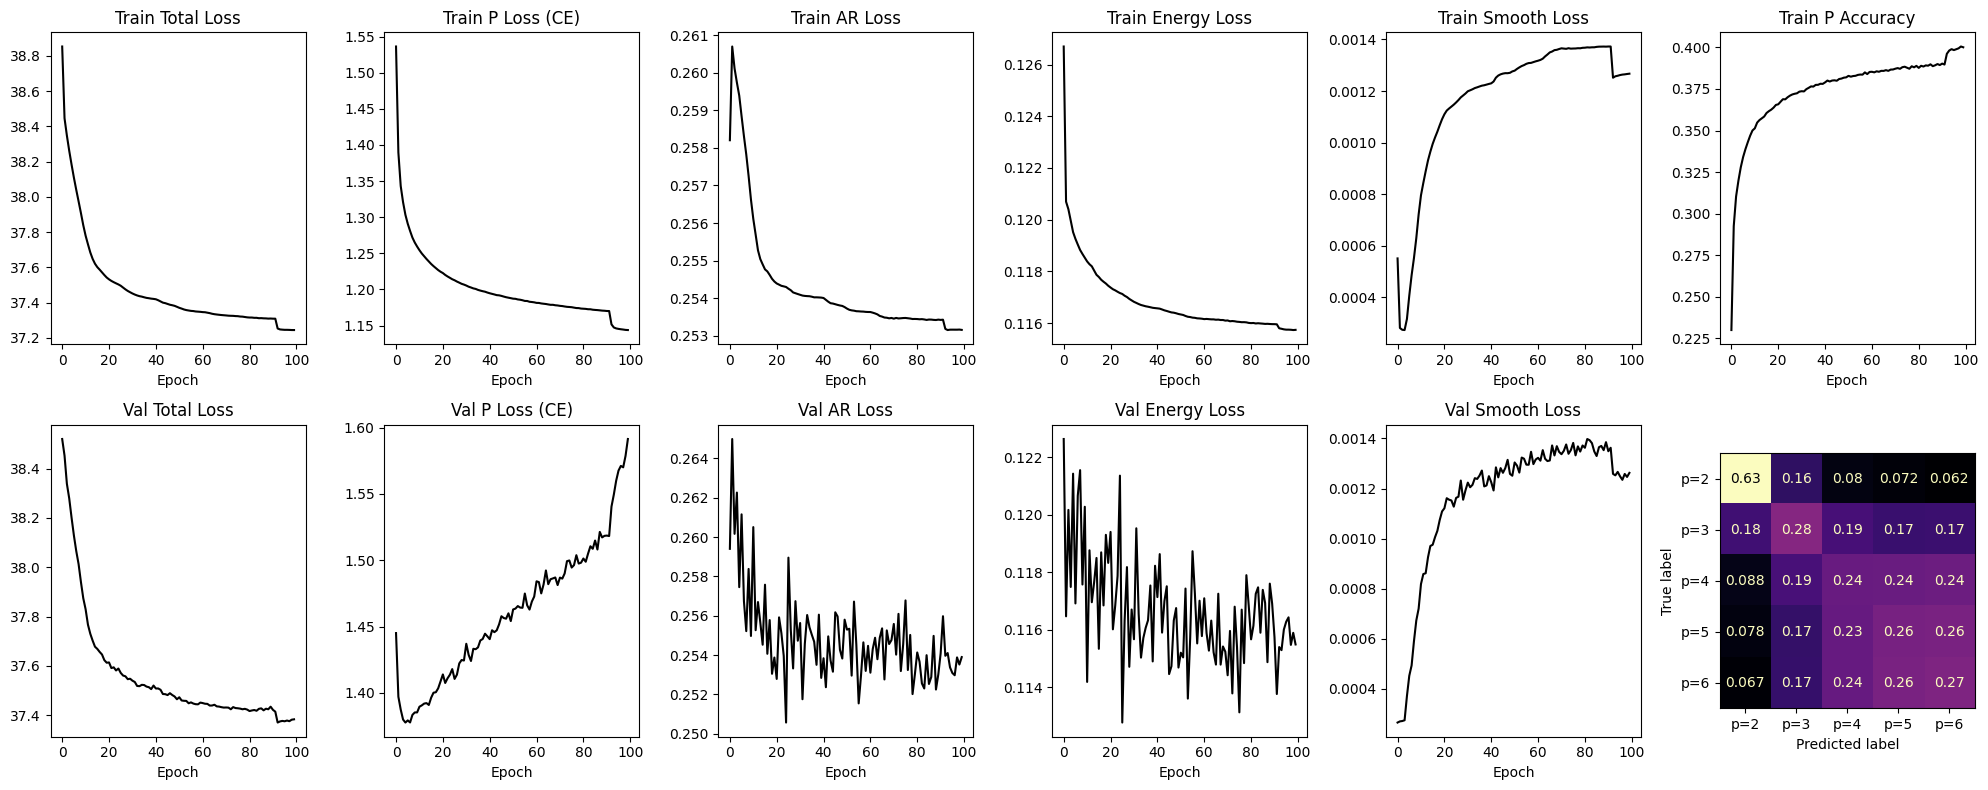

In [7]:
conf = {
    "lambda_ar": 100,
    "lambda_p": 0.2,
    "lambda_order": 0,
    "lambda_energy": 100,
    "lambda_smooth": 100,
}

model, history = do_bench_on_config(conf)
plot_history(history, model=model, val_loader=val_loader, device=device)

In [8]:
# grid_values = [0, 2, 4]
# results = {}

# for lam_ar in grid_values:
#     for lam_p in grid_values:
#         for lam_smooth in grid_values:
#             for lam_energy in grid_values:
#                 label = f"ar={lam_ar}, p={lam_p}, smooth={lam_smooth}, energy={lam_energy}"
#                 print(f"\n{'='*50}\n{label}\n{'='*50}")
#                 conf = {
#                     "lambda_ar": lam_ar,
#                     "lambda_p": lam_p,
#                     "lambda_order": 0,
#                     "lambda_energy": lam_energy,
#                     "lambda_smooth": lam_smooth,
#                 }
#                 model, history = do_bench_on_config(conf)
#                 plot_history(history, model=model, val_loader=val_loader, device=device)
#                 plt.suptitle(label, fontsize=12)
#                 plt.tight_layout()
#                 plt.show()
#                 results[label] = history

In [9]:
# # Save model
# torch.save(model.state_dict(), "base_model.pt")
# print("Model saved to base_model.pt")

In [10]:
import json

with open("history_update.json", "w") as f:
    json.dump(history, f, indent=2)

In [11]:
# # # Load model
# model = DeepLagEmbed(seq_len=600, n_classes=5, max_ar_order=6, hidden_dim=128)
# model.load_state_dict(torch.load("base_model.pt", map_location=device))
# model = model.to(device)
# model.eval()
# print("Model loaded from base_model.pt")